In [1]:
import zipfile

zip_path = r"OneDrive/Desktop/FINAL-ML PROJECT/scientific.zip"
extract_path = r"OneDrive/Desktop/FINAL-ML PROJECT/scientific"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [3]:
# ── CELL 1 ── Install / Import Libraries ────────────────────
import re
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from collections import Counter

In [5]:
# --- SciQ samples (question + support concatenated) ---------
sciq_raw_samples = [
    "What is the process by which Plants convert sunlight into energy? "
    "Photosynthesis occurs in the chloroplasts; using CO2, H2O & light!",
 
    "Which Gas is most abundant in Earth's Atmosphere (78%)? "
    "Nitrogen (N2) makes up ~78% of the atmosphere, O2 ~21%, & Ar ~0.93%.",
 
    "What force keeps Planets in orbit around the Sun? "
    "Gravity -- discovered by Newton in 1687 -- acts as a centripetal force "
    "pulling planets (mass=m) toward the Sun.",
 
    "What type of rock is formed from cooling Magma/Lava? "
    "Igneous rocks (e.g., basalt & granite) form when molten rock cools "
    "either underground (intrusive) or at Earth's surface (extrusive).",
 
    "What is the powerhouse of the Cell? "
    "The mitochondria (sing. mitochondrion) produce ATP via cellular "
    "respiration: C6H12O6 + 6O2 → 6CO2 + 6H2O + 38 ATP.",
]
 
# --- MTSamples raw clinical transcription samples -----------
mtsamples_raw_samples = [
    "CHIEF COMPLAINT: Patient, 52-yr-old male, presents w/ chest pain "
    "(7/10), onset 3hrs ago. BP: 140/90 mmHg. EKG & troponin ordered.",
 
    "Dx: Type-2 Diabetes Mellitus (T2DM). HbA1c=8.3%. "
    "Rx: Metformin 500mg BID + lifestyle modifications. F/U in 3 months.",
 
    "POST-OP NOTE -- Appendectomy (laparoscopic). Pt. tolerated procedure "
    "well. Blood-loss: ~50ml. Vitals stable. D/C planned for 48-72hrs.",
 
    "NEUROLOGY CONSULT: 67 y/o F with H/O hypertension & atrial-fib. "
    "MRI brain: 1.2cm lacunar infarct in L. internal capsule. NIH=4.",
 
    "Rx: Amoxicillin-Clavulanate 875/125mg PO q12h x 10days for "
    "community-acquired pneumonia (CAP). CXR: RLL infiltrate confirmed.",
]
 

In [7]:
def clean_text(text):
    """Mirrors the clean_text() pipeline used in the thesis."""
    # Step 1 – lowercase
    text = text.lower()
    # Step 2 – remove non-alphabetic characters (keep spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Step 3 – collapse multiple whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text
 
 
sciq_clean_samples    = [clean_text(t) for t in sciq_raw_samples]
mtsamples_clean_samples = [clean_text(t) for t in mtsamples_raw_samples]

In [9]:
def token_stats(texts):
    """Return avg token count, vocab size, special-char ratio, upper ratio."""
    all_tokens, upper_count, special_count, total_chars = [], 0, 0, 0
    for t in texts:
        tokens = t.split()
        all_tokens.extend(tokens)
        upper_count  += sum(1 for c in t if c.isupper())
        special_count += sum(1 for c in t if not c.isalnum() and not c.isspace())
        total_chars  += len(t)
    vocab = len(set(all_tokens))
    avg_tok = len(all_tokens) / len(texts)
    upper_ratio   = upper_count   / total_chars * 100 if total_chars else 0
    special_ratio = special_count / total_chars * 100 if total_chars else 0
    return vocab, avg_tok, special_ratio, upper_ratio

C:\Users\nissy\AppData\Local\Temp\ipykernel_24728\1877201004.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


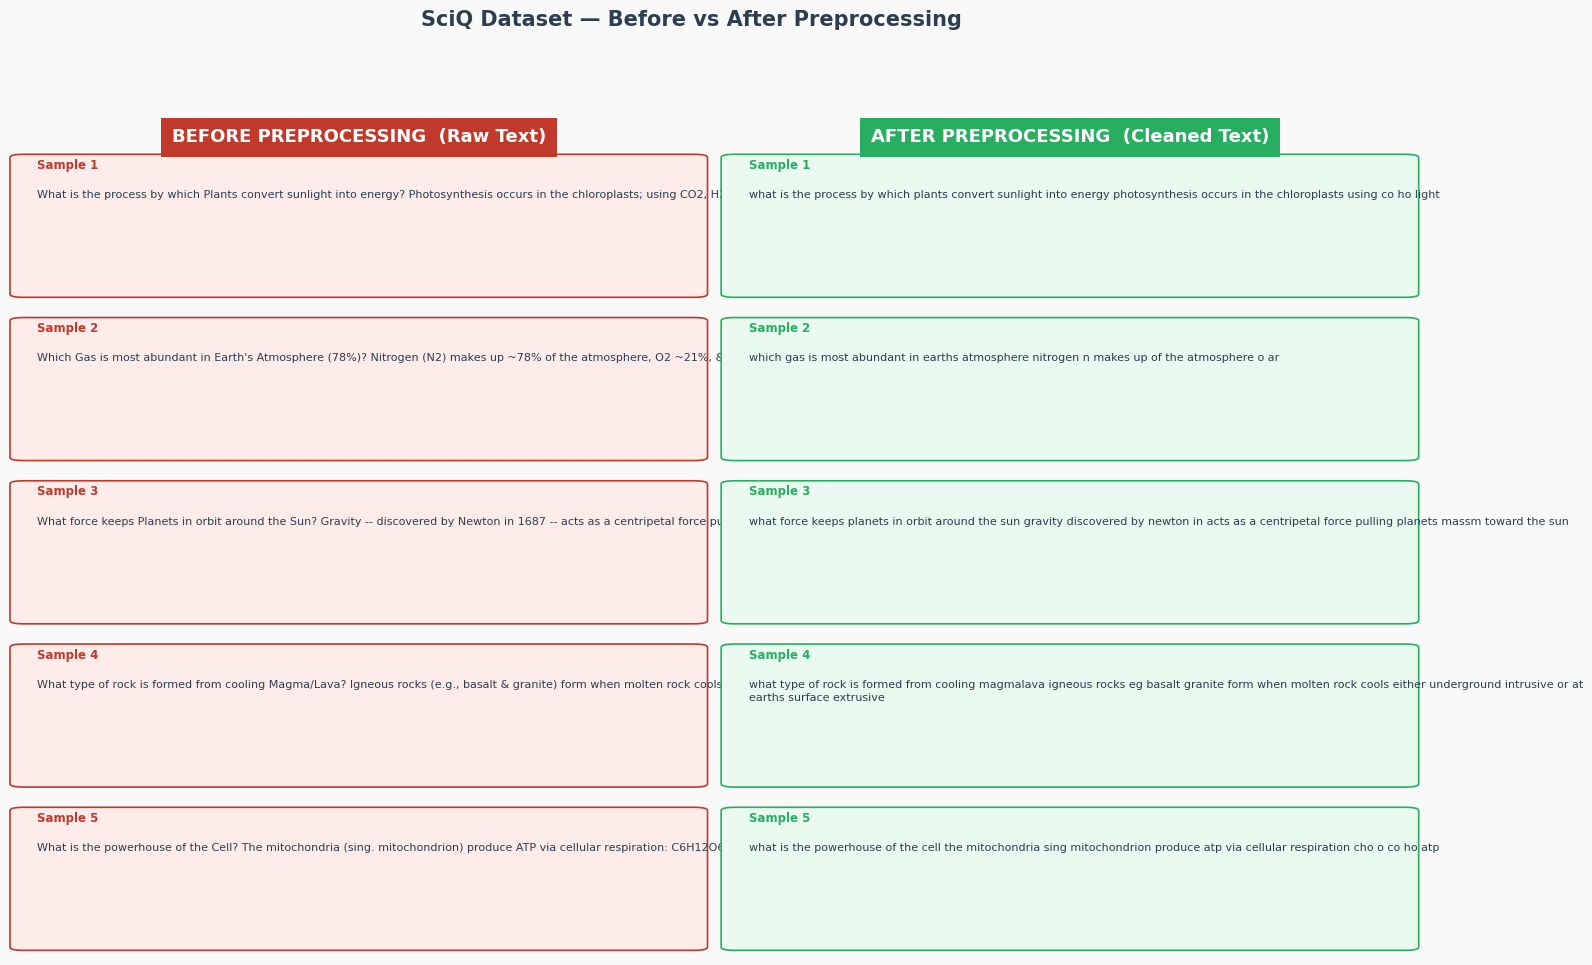

✅  Saved → sciq_before_after_preprocessing.png


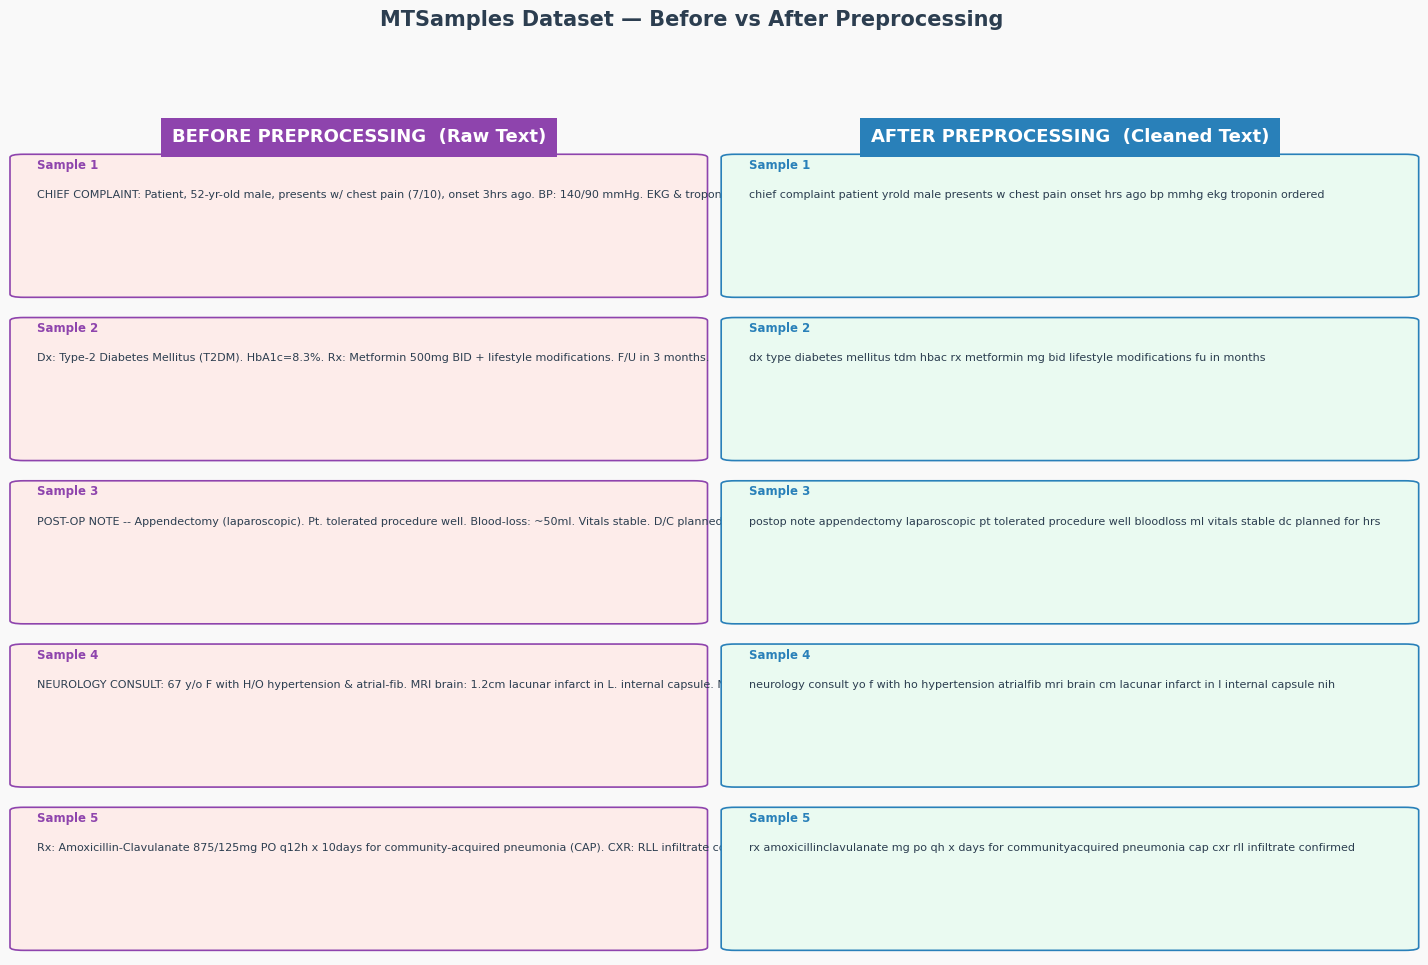

✅  Saved → mtsamples_before_after_preprocessing.png


In [11]:
def plot_before_after_text(raw_list, clean_list, dataset_name, filename,
                            color_raw="#c0392b", color_clean="#27ae60"):
    """
    Draws a 2-column table showing raw text (left) vs cleaned text (right).
    """
    n = len(raw_list)
    fig, axes = plt.subplots(n, 2, figsize=(18, n * 2.1),
                             gridspec_kw={"hspace": 0.05, "wspace": 0.04})
    fig.patch.set_facecolor("#f9f9f9")
 
    col_labels = ["BEFORE PREPROCESSING  (Raw Text)",
                  "AFTER PREPROCESSING  (Cleaned Text)"]
    col_colors = [color_raw, color_clean]
 
    for col, (label, col_color) in enumerate(zip(col_labels, col_colors)):
        axes[0, col].set_title(label, fontsize=13, fontweight="bold",
                               color="white", pad=0,
                               bbox=dict(boxstyle="square,pad=0.6",
                                         facecolor=col_color, edgecolor="none"))
 
    for row in range(n):
        raw_text   = raw_list[row]
        clean_text_val = clean_list[row]
 
        for col, (text, col_color) in enumerate(
                zip([raw_text, clean_text_val], col_colors)):
 
            ax = axes[row, col]
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.axis("off")
 
            # row background
            bg_color = "#fdecea" if col == 0 else "#eafaf1"
            ax.add_patch(mpatches.FancyBboxPatch(
                (0.01, 0.05), 0.98, 0.88,
                boxstyle="round,pad=0.02",
                facecolor=bg_color, edgecolor=col_color,
                linewidth=1.2, transform=ax.transAxes, clip_on=False))
 
            # sample label
            ax.text(0.03, 0.92, f"Sample {row + 1}",
                    transform=ax.transAxes, fontsize=8.5,
                    color=col_color, fontweight="bold", va="top")
 
            # main text (wrapped)
            ax.text(0.03, 0.72, text,
                    transform=ax.transAxes, fontsize=8,
                    color="#2c3e50", va="top",
                    wrap=True,
                    multialignment="left",
                    linespacing=1.4,
                    bbox=dict(facecolor="none", edgecolor="none"),
                    # force wrapping via clip
                    clip_on=False)
 
    fig.suptitle(f"{dataset_name} Dataset — Before vs After Preprocessing",
                 fontsize=15, fontweight="bold", color="#2c3e50", y=1.01)
 
    plt.tight_layout()
    plt.savefig(filename, dpi=180, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"✅  Saved → {filename}")
 
 
plot_before_after_text(
    sciq_raw_samples, sciq_clean_samples,
    dataset_name="SciQ",
    filename="sciq_before_after_preprocessing.png",
    color_raw="#c0392b", color_clean="#27ae60"
)
 
plot_before_after_text(
    mtsamples_raw_samples, mtsamples_clean_samples,
    dataset_name="MTSamples",
    filename="mtsamples_before_after_preprocessing.png",
    color_raw="#8e44ad", color_clean="#2980b9"
)
 

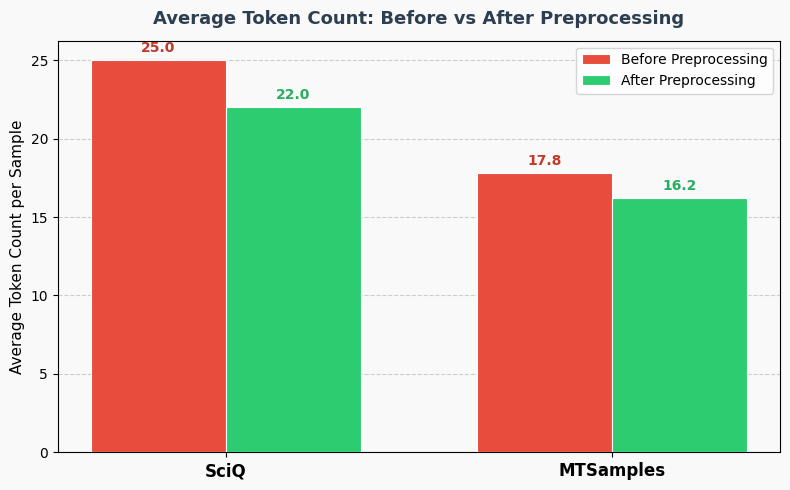

✅  Saved → token_count_before_after.png


In [13]:
def plot_token_count_comparison():
    datasets   = ["SciQ", "MTSamples"]
    raw_groups = [sciq_raw_samples, mtsamples_raw_samples]
    cln_groups = [sciq_clean_samples, mtsamples_clean_samples]
 
    raw_avg, cln_avg = [], []
    for raw, cln in zip(raw_groups, cln_groups):
        raw_avg.append(np.mean([len(t.split()) for t in raw]))
        cln_avg.append(np.mean([len(t.split()) for t in cln]))
 
    x     = np.arange(len(datasets))
    width = 0.35
 
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor("#f9f9f9")
    ax.set_facecolor("#f9f9f9")
 
    bars1 = ax.bar(x - width/2, raw_avg, width, label="Before Preprocessing",
                   color="#e74c3c", edgecolor="white", linewidth=0.8,
                   zorder=3)
    bars2 = ax.bar(x + width/2, cln_avg, width, label="After Preprocessing",
                   color="#2ecc71", edgecolor="white", linewidth=0.8,
                   zorder=3)
 
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, fontsize=12, fontweight="bold")
    ax.set_ylabel("Average Token Count per Sample", fontsize=11)
    ax.set_title("Average Token Count: Before vs After Preprocessing",
                 fontsize=13, fontweight="bold", color="#2c3e50", pad=12)
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle="--", alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
 
    for bar in bars1:
        ax.annotate(f"{bar.get_height():.1f}",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=10,
                    color="#c0392b", fontweight="bold")
    for bar in bars2:
        ax.annotate(f"{bar.get_height():.1f}",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=10,
                    color="#27ae60", fontweight="bold")
 
    plt.tight_layout()
    plt.savefig("token_count_before_after.png", dpi=180,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print("✅  Saved → token_count_before_after.png")
 
 
plot_token_count_comparison()

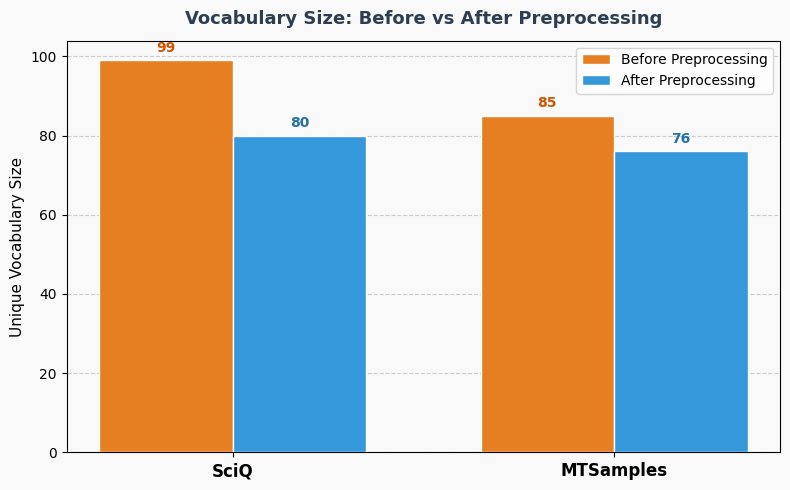

✅  Saved → vocab_reduction_before_after.png


In [15]:
def plot_vocab_reduction():
    datasets   = ["SciQ", "MTSamples"]
    raw_groups = [sciq_raw_samples, mtsamples_raw_samples]
    cln_groups = [sciq_clean_samples, mtsamples_clean_samples]
 
    raw_vocab, cln_vocab = [], []
    for raw, cln in zip(raw_groups, cln_groups):
        raw_vocab.append(len(set(" ".join(raw).split())))
        cln_vocab.append(len(set(" ".join(cln).split())))
 
    x     = np.arange(len(datasets))
    width = 0.35
 
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor("#f9f9f9")
    ax.set_facecolor("#f9f9f9")
 
    bars1 = ax.bar(x - width/2, raw_vocab, width, label="Before Preprocessing",
                   color="#e67e22", edgecolor="white", zorder=3)
    bars2 = ax.bar(x + width/2, cln_vocab, width, label="After Preprocessing",
                   color="#3498db", edgecolor="white", zorder=3)
 
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, fontsize=12, fontweight="bold")
    ax.set_ylabel("Unique Vocabulary Size", fontsize=11)
    ax.set_title("Vocabulary Size: Before vs After Preprocessing",
                 fontsize=13, fontweight="bold", color="#2c3e50", pad=12)
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle="--", alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
 
    for bar in bars1:
        ax.annotate(f"{int(bar.get_height())}",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=10,
                    color="#d35400", fontweight="bold")
    for bar in bars2:
        ax.annotate(f"{int(bar.get_height())}",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=10,
                    color="#2471a3", fontweight="bold")
 
    plt.tight_layout()
    plt.savefig("vocab_reduction_before_after.png", dpi=180,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print("✅  Saved → vocab_reduction_before_after.png")
 
 
plot_vocab_reduction()
 

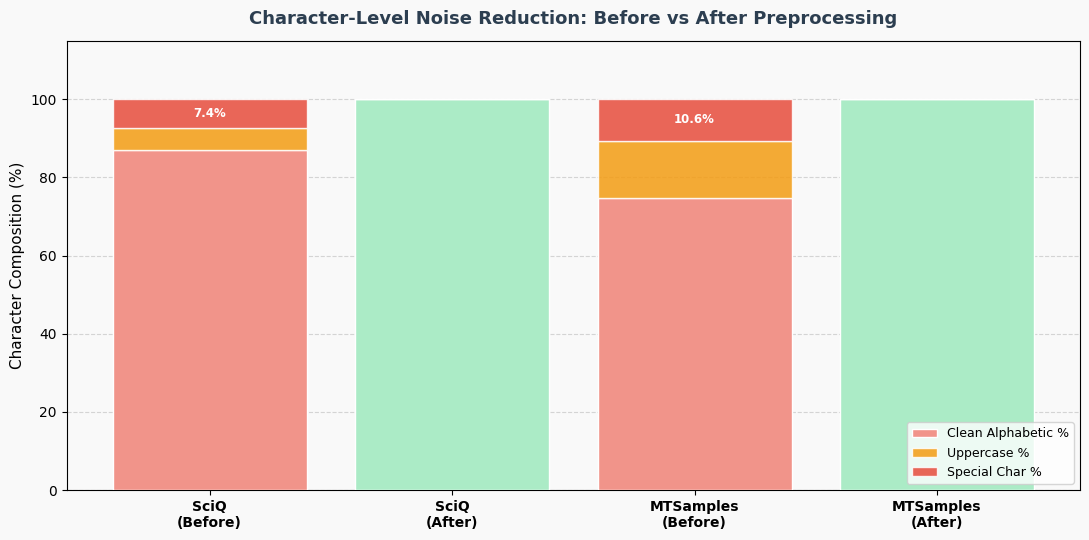

✅  Saved → noise_reduction_before_after.png


In [17]:
def plot_noise_reduction():
    datasets   = ["SciQ\n(Before)", "SciQ\n(After)",
                  "MTSamples\n(Before)", "MTSamples\n(After)"]
 
    groups = [
        (sciq_raw_samples,        "#e74c3c"),
        (sciq_clean_samples,      "#27ae60"),
        (mtsamples_raw_samples,   "#8e44ad"),
        (mtsamples_clean_samples, "#2980b9"),
    ]
 
    upper_ratios, special_ratios, clean_ratios = [], [], []
    for texts, _ in groups:
        joined = " ".join(texts)
        total  = len(joined)
        up  = sum(1 for c in joined if c.isupper()) / total * 100
        sp  = sum(1 for c in joined
                  if not c.isalnum() and not c.isspace()) / total * 100
        cl  = 100 - up - sp
        upper_ratios.append(up)
        special_ratios.append(sp)
        clean_ratios.append(cl)
 
    x      = np.arange(len(datasets))
    colors = [g[1] for g in groups]
 
    fig, ax = plt.subplots(figsize=(11, 5.5))
    fig.patch.set_facecolor("#f9f9f9")
    ax.set_facecolor("#f9f9f9")
 
    bar_clean   = ax.bar(x, clean_ratios,   label="Clean Alphabetic %",
                         color=["#abebc6" if i % 2 == 1 else "#f1948a"
                                for i in range(len(x))],
                         edgecolor="white", zorder=3)
    bar_upper   = ax.bar(x, upper_ratios,   bottom=clean_ratios,
                         label="Uppercase %",
                         color="#f39c12", alpha=0.85,
                         edgecolor="white", zorder=3)
    bar_special = ax.bar(x, special_ratios,
                         bottom=[c + u for c, u in
                                 zip(clean_ratios, upper_ratios)],
                         label="Special Char %",
                         color="#e74c3c", alpha=0.85,
                         edgecolor="white", zorder=3)
 
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, fontsize=10, fontweight="bold")
    ax.set_ylabel("Character Composition (%)", fontsize=11)
    ax.set_title(
        "Character-Level Noise Reduction: Before vs After Preprocessing",
        fontsize=13, fontweight="bold", color="#2c3e50", pad=12)
    ax.legend(fontsize=9, loc="lower right")
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_ylim(0, 115)
    ax.set_axisbelow(True)
 
    for bar in bar_special:
        h = bar.get_height()
        if h > 0.5:
            ax.annotate(f"{h:.1f}%",
                        xy=(bar.get_x() + bar.get_width() / 2,
                            bar.get_y() + h / 2),
                        ha="center", va="center",
                        fontsize=8.5, color="white", fontweight="bold")
 
    plt.tight_layout()
    plt.savefig("noise_reduction_before_after.png", dpi=180,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print("✅  Saved → noise_reduction_before_after.png")
 
 
plot_noise_reduction()

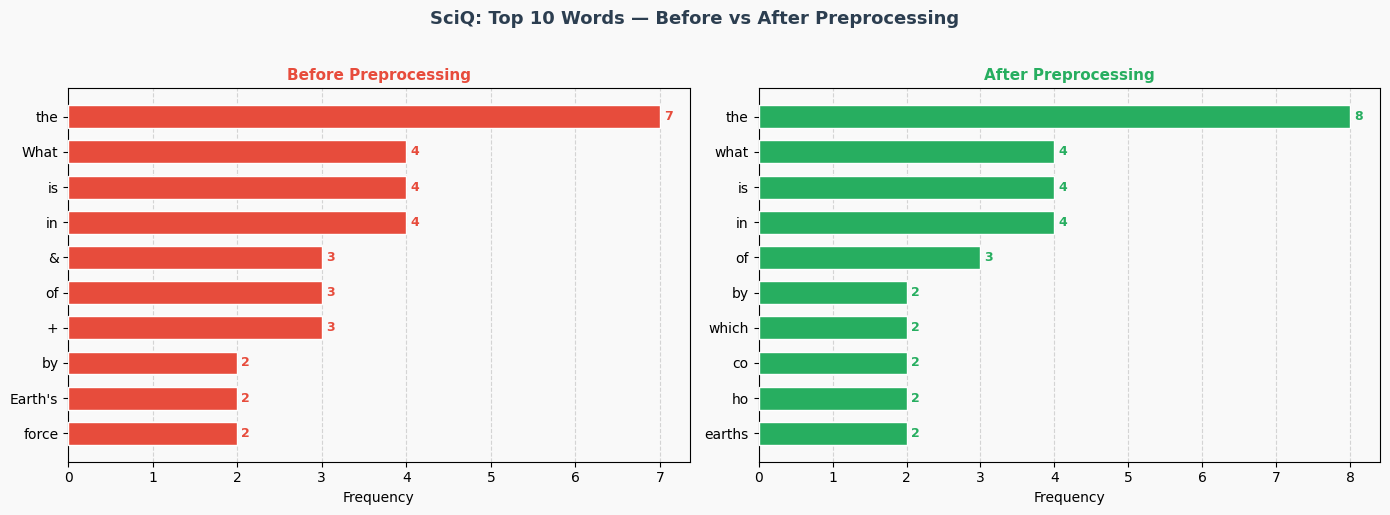

✅  Saved → sciq_word_freq_before_after.png


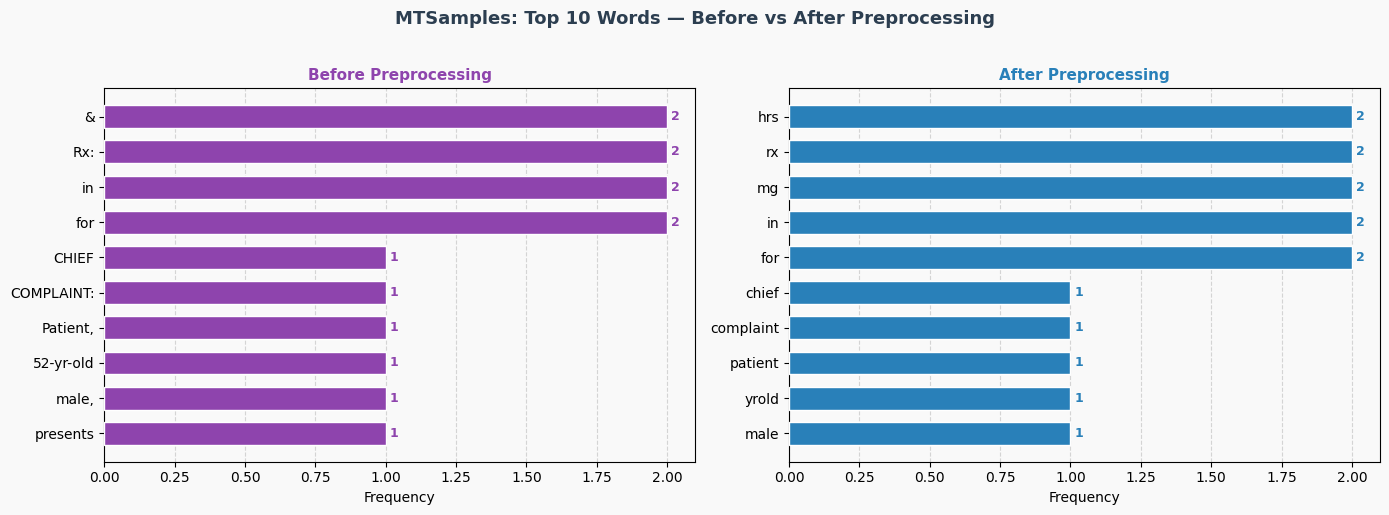

✅  Saved → mtsamples_word_freq_before_after.png


In [19]:
def plot_word_freq_before_after(raw_list, clean_list,
                                dataset_name, filename,
                                top_n=10,
                                color_raw="#e74c3c",
                                color_clean="#27ae60"):
    raw_tokens   = " ".join(raw_list).split()
    clean_tokens = " ".join(clean_list).split()
 
    raw_freq   = Counter(raw_tokens).most_common(top_n)
    clean_freq = Counter(clean_tokens).most_common(top_n)
 
    raw_words,   raw_counts   = zip(*raw_freq)
    clean_words, clean_counts = zip(*clean_freq)
 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#f9f9f9")
    fig.suptitle(
        f"{dataset_name}: Top {top_n} Words — Before vs After Preprocessing",
        fontsize=13, fontweight="bold", color="#2c3e50", y=1.02)
 
    for ax, words, counts, title, color in zip(
            axes,
            [raw_words, clean_words],
            [raw_counts, clean_counts],
            ["Before Preprocessing", "After Preprocessing"],
            [color_raw, color_clean]):
 
        ax.set_facecolor("#f9f9f9")
        y_pos = np.arange(len(words))
        bars = ax.barh(y_pos, counts, color=color, edgecolor="white",
                       height=0.65, zorder=3)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(words, fontsize=10)
        ax.invert_yaxis()
        ax.set_xlabel("Frequency", fontsize=10)
        ax.set_title(title, fontsize=11, fontweight="bold", color=color)
        ax.xaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
        ax.set_axisbelow(True)
 
        for bar in bars:
            ax.annotate(f"{int(bar.get_width())}",
                        xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                        xytext=(3, 0), textcoords="offset points",
                        va="center", ha="left", fontsize=9,
                        color=color, fontweight="bold")
 
    plt.tight_layout()
    plt.savefig(filename, dpi=180, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"✅  Saved → {filename}")
 
 
plot_word_freq_before_after(
    sciq_raw_samples, sciq_clean_samples,
    dataset_name="SciQ", top_n=10,
    filename="sciq_word_freq_before_after.png",
    color_raw="#e74c3c", color_clean="#27ae60"
)
 
plot_word_freq_before_after(
    mtsamples_raw_samples, mtsamples_clean_samples,
    dataset_name="MTSamples", top_n=10,
    filename="mtsamples_word_freq_before_after.png",
    color_raw="#8e44ad", color_clean="#2980b9"
)
 

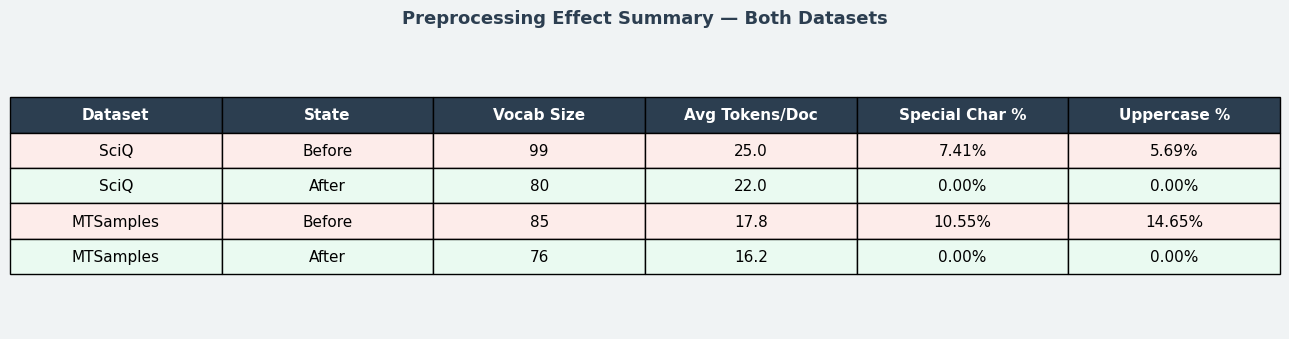

✅  Saved → preprocessing_summary_stats.png


In [21]:
def plot_summary_stats_table():
    fig, ax = plt.subplots(figsize=(13, 3.5))
    fig.patch.set_facecolor("#f0f3f4")
    ax.axis("off")
 
    columns = ["Dataset", "State",
               "Vocab Size", "Avg Tokens/Doc",
               "Special Char %", "Uppercase %"]
 
    rows = []
    for name, raw, cln in [
        ("SciQ",      sciq_raw_samples,      sciq_clean_samples),
        ("SciQ",      sciq_raw_samples,      sciq_clean_samples),
        ("MTSamples", mtsamples_raw_samples, mtsamples_clean_samples),
        ("MTSamples", mtsamples_raw_samples, mtsamples_clean_samples),
    ]:
        pass  # built below
 
    data_rows = []
    for name, raw_list, cln_list in [
        ("SciQ",      sciq_raw_samples,      sciq_clean_samples),
        ("MTSamples", mtsamples_raw_samples, mtsamples_clean_samples),
    ]:
        for state, texts in [("Before", raw_list), ("After", cln_list)]:
            joined = " ".join(texts)
            total  = len(joined) or 1
            vocab  = len(set(joined.split()))
            avg_t  = np.mean([len(t.split()) for t in texts])
            sp_r   = sum(1 for c in joined
                         if not c.isalnum() and not c.isspace()) / total * 100
            up_r   = sum(1 for c in joined if c.isupper()) / total * 100
            data_rows.append([name, state,
                               str(vocab),
                               f"{avg_t:.1f}",
                               f"{sp_r:.2f}%",
                               f"{up_r:.2f}%"])
 
    table = ax.table(
        cellText=data_rows,
        colLabels=columns,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2.0)
 
    # Header styling
    for j in range(len(columns)):
        table[0, j].set_facecolor("#2c3e50")
        table[0, j].set_text_props(color="white", fontweight="bold")
 
    # Row colouring
    row_colors = {
        "Before": "#fdecea",
        "After":  "#eafaf1",
    }
    for i, row in enumerate(data_rows, start=1):
        state = row[1]
        for j in range(len(columns)):
            table[i, j].set_facecolor(row_colors.get(state, "white"))
 
    ax.set_title("Preprocessing Effect Summary — Both Datasets",
                 fontsize=13, fontweight="bold", color="#2c3e50",
                 pad=14)
 
    plt.tight_layout()
    plt.savefig("preprocessing_summary_stats.png", dpi=180,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print("✅  Saved → preprocessing_summary_stats.png")
 
 
plot_summary_stats_table()

In [23]:
print("\n" + "="*60)
print("ALL GENERATED IMAGES (copy these to your thesis folder):")
print("="*60)
images = [
    "sciq_before_after_preprocessing.png",
    "mtsamples_before_after_preprocessing.png",
    "token_count_before_after.png",
    "vocab_reduction_before_after.png",
    "noise_reduction_before_after.png",
    "sciq_word_freq_before_after.png",
    "mtsamples_word_freq_before_after.png",
    "preprocessing_summary_stats.png",
]
for img in images:
    print(f"  ✅  {img}")
print("="*60)
print("Use these in your LaTeX thesis like:")
print(r"  \includegraphics[width=\linewidth]{sciq_before_after_preprocessing.png}")


ALL GENERATED IMAGES (copy these to your thesis folder):
  ✅  sciq_before_after_preprocessing.png
  ✅  mtsamples_before_after_preprocessing.png
  ✅  token_count_before_after.png
  ✅  vocab_reduction_before_after.png
  ✅  noise_reduction_before_after.png
  ✅  sciq_word_freq_before_after.png
  ✅  mtsamples_word_freq_before_after.png
  ✅  preprocessing_summary_stats.png
Use these in your LaTeX thesis like:
  \includegraphics[width=\linewidth]{sciq_before_after_preprocessing.png}


In [3]:
import os
os.listdir(extract_path)


['test.csv', 'train.csv', 'validation.csv']

In [5]:
import pandas as pd

df = pd.read_csv(r"OneDrive/Desktop/FINAL-ML PROJECT/scientific/train.csv")


In [7]:
print(df.columns)
df.head()


Index(['question', 'distractor3', 'distractor1', 'distractor2',
       'correct_answer', 'support'],
      dtype='object')


,question,distractor3,distractor1,distractor2,correct_answer,support
0,What type of organism is commonly used in prep...,viruses,protozoa,gymnosperms,mesophilic organisms,"Mesophiles grow best in moderate temperature, ..."
1,What phenomenon makes global winds blow northe...,tropical effect,muon effect,centrifugal effect,coriolis effect,Without Coriolis Effect the global winds would...
2,Changes from a less-ordered state to a more-or...,endothermic,unbalanced,reactive,exothermic,Summary Changes of state are examples of phase...
3,What is the least dangerous radioactive decay?,zeta decay,beta decay,gamma decay,alpha decay,All radioactive decay is dangerous to living t...
4,Kilauea in hawaii is the world’s most continuo...,magma,greenhouse gases,carbon and smog,smoke and ash,Example 3.5 Calculating Projectile Motion: Hot...


In [9]:
df = df[['question','support','correct_answer']]
df = df.dropna()


In [11]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_support'] = df['support'].apply(clean_text)


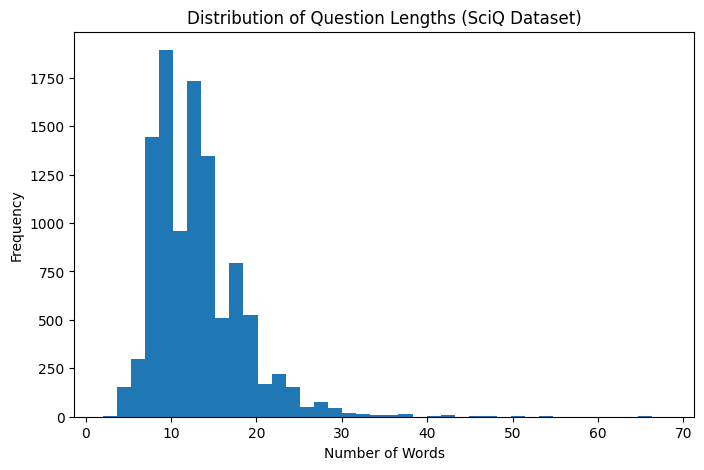

In [13]:
import matplotlib.pyplot as plt

df['question_length'] = df['question'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
plt.hist(df['question_length'], bins=40)
plt.title("Distribution of Question Lengths (SciQ Dataset)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

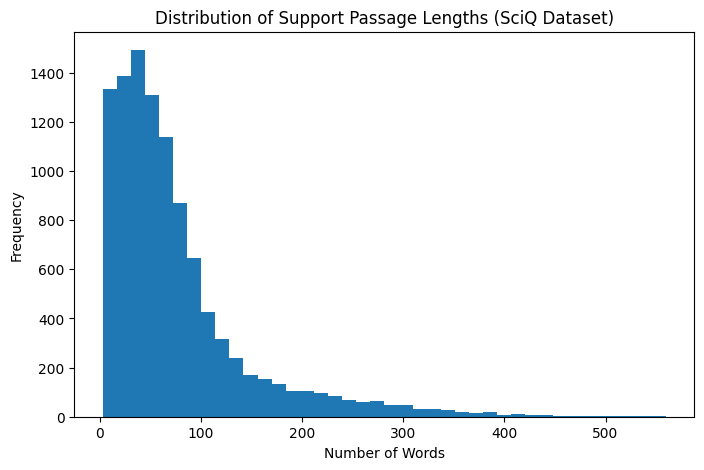

In [15]:
df['support_length'] = df['support'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
plt.hist(df['support_length'], bins=40)
plt.title("Distribution of Support Passage Lengths (SciQ Dataset)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [17]:
!pip install wordcloud

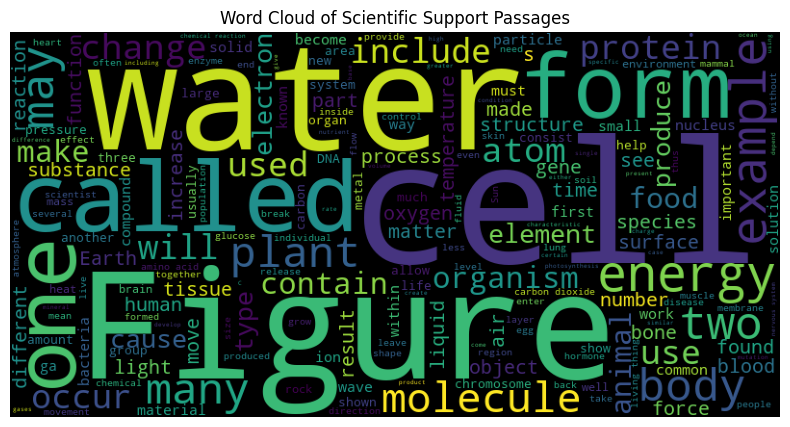

In [19]:
from wordcloud import WordCloud

text = " ".join(df['support'])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Scientific Support Passages")
plt.show()

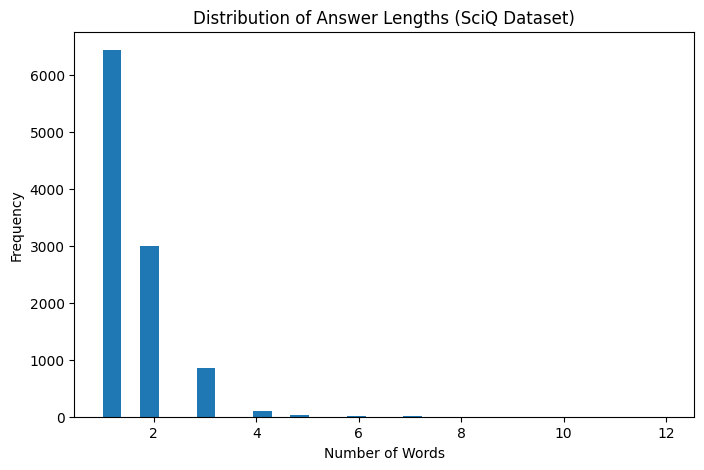

In [21]:
df['answer_length'] = df['correct_answer'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
plt.hist(df['answer_length'], bins=30)
plt.title("Distribution of Answer Lengths (SciQ Dataset)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.savefig("answer_length_distribution.png")
plt.show()

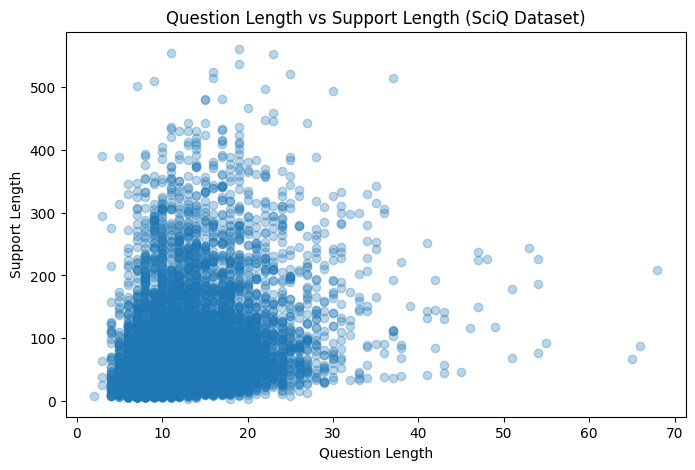

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(df['question_length'], df['support_length'], alpha=0.3)
plt.title("Question Length vs Support Length (SciQ Dataset)")
plt.xlabel("Question Length")
plt.ylabel("Support Length")
plt.savefig("question_vs_support_length.png")
plt.show()

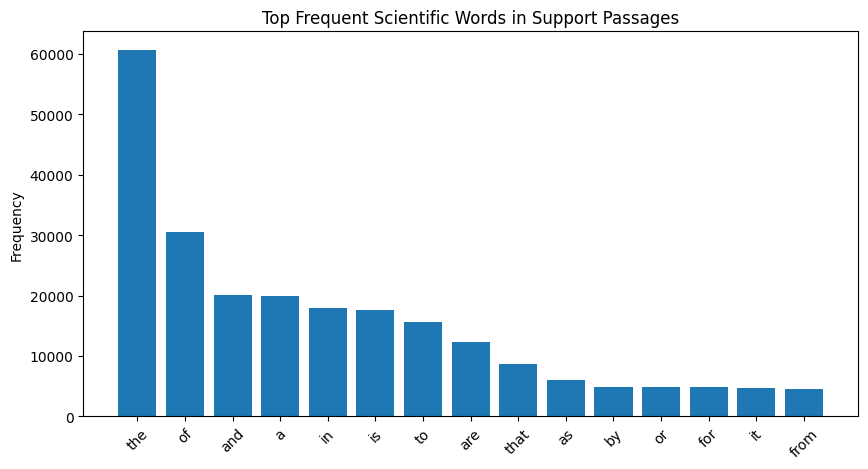

In [25]:
from collections import Counter

all_words = " ".join(df['clean_support']).split()
common_words = Counter(all_words).most_common(15)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Frequent Scientific Words in Support Passages")
plt.ylabel("Frequency")
plt.savefig("top_scientific_words.png")
plt.show()

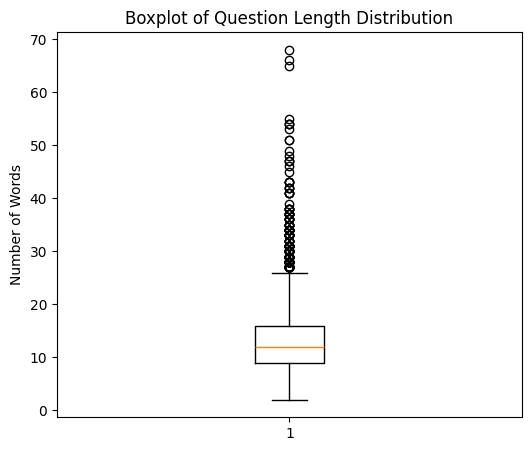

In [27]:
plt.figure(figsize=(6,5))
plt.boxplot(df['question_length'])
plt.title("Boxplot of Question Length Distribution")
plt.ylabel("Number of Words")
plt.savefig("question_length_boxplot.png")
plt.show()

In [29]:
import numpy as np

dataset_stats = {
    "Total Samples": len(df),
    "Avg Question Length": np.mean(df['question_length']),
    "Avg Support Length": np.mean(df['support_length']),
    "Avg Answer Length": np.mean(df['answer_length']),
    "Max Question Length": np.max(df['question_length']),
    "Max Support Length": np.max(df['support_length']),
    "Vocabulary Size": len(set(" ".join(df['clean_support']).split()))
}

dataset_stats

{'Total Samples': 10481,
 'Avg Question Length': 12.99379830168877,
 'Avg Support Length': 75.86890563877492,
 'Avg Answer Length': 1.5145501383455777,
 'Max Question Length': 68,
 'Max Support Length': 560,
 'Vocabulary Size': 22723}

In [31]:
stats_df = pd.DataFrame(dataset_stats.items(), columns=["Metric", "Value"])
stats_df

,Metric,Value
0,Total Samples,10481.000000
1,Avg Question Length,12.993798
2,Avg Support Length,75.868906
3,Avg Answer Length,1.514550
4,Max Question Length,68.000000
5,Max Support Length,560.000000
6,Vocabulary Size,22723.000000


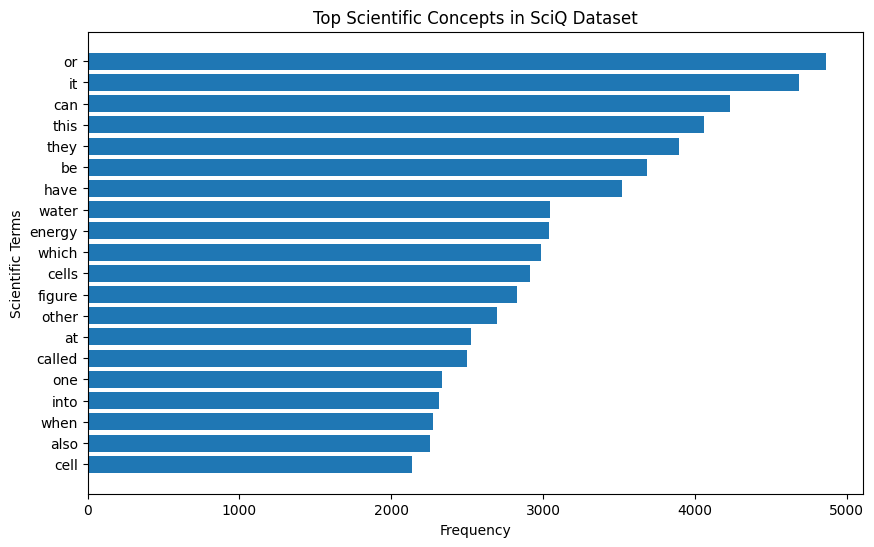

In [33]:
from collections import Counter
import matplotlib.pyplot as plt

# combine all support text
all_words = " ".join(df['clean_support']).split()

# remove very common stopwords manually (simple filter)
stopwords = {'the','and','is','in','of','to','a','that','for','as','with','on','by','an','are','from'}

filtered_words = [w for w in all_words if w not in stopwords]

# get top 20 scientific terms
top_words = Counter(filtered_words).most_common(20)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

# plot horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(words[::-1], counts[::-1])
plt.title("Top Scientific Concepts in SciQ Dataset")
plt.xlabel("Frequency")
plt.ylabel("Scientific Terms")
plt.savefig("top_scientific_terms_sciq.png")
plt.show()

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer()
bow_vectors = bow.fit_transform(df['clean_support'])


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
tfidf_vectors = tfidf.fit_transform(df['clean_support'])


In [17]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")
embedding_vectors = embedder.encode(df['support'].tolist())


In [19]:
from sklearn.metrics.pairwise import cosine_similarity


In [67]:
user_question = input("Enter question:")

clean_q = clean_text(user_question)


Enter question: who is the present prime minister of India in 2026?


In [23]:
q_vec = bow.transform([clean_q])
similarity = cosine_similarity(q_vec, bow_vectors)


In [25]:
q_vec = tfidf.transform([clean_q])
similarity = cosine_similarity(q_vec, tfidf_vectors)


In [27]:
q_embed = embedder.encode([user_question])
similarity = cosine_similarity(q_embed, embedding_vectors)


In [29]:
top_k = 3
indices = similarity.argsort()[0][-top_k:][::-1]


In [31]:
pip install wikipedia



  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11705 sha256=505415a9d0d6983e6ad8a874cc9d97248852b2b8876308dbdb0c4936f4fd2fd3
  Stored in directory: c:\users\nissy\appdata\local\pip\cache\wheels\63\47\7c\a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


In [69]:
import wikipedia

try:
    wiki_context = wikipedia.summary(user_question, sentences=3)
except:
    wiki_context = ""


In [70]:
context = ""

for i in indices:
    context += df.iloc[i]['support'] + "\n"

final_context = context + wiki_context


In [73]:
from transformers import pipeline

generator = pipeline("text2text-generation",
                     model="google/flan-t5-base")

prompt = f"""
Use context to answer.

Context:
{final_context}

Question:
{user_question}

Answer:
"""

answer = generator(prompt)[0]['generated_text']
print(answer)


Device set to use cpu


unanswerable


In [75]:
!pip install pandas numpy scikit-learn sentence-transformers transformers wikipedia


In [1]:
import pandas as pd
import numpy as np
import wikipedia

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

from transformers import pipeline


In [2]:
df = pd.read_csv(r"OneDrive/Desktop/FINAL-ML PROJECT/scientific/train.csv")   # change path if needed

df.head()


,question,distractor3,distractor1,distractor2,correct_answer,support
0,What type of organism is commonly used in prep...,viruses,protozoa,gymnosperms,mesophilic organisms,"Mesophiles grow best in moderate temperature, ..."
1,What phenomenon makes global winds blow northe...,tropical effect,muon effect,centrifugal effect,coriolis effect,Without Coriolis Effect the global winds would...
2,Changes from a less-ordered state to a more-or...,endothermic,unbalanced,reactive,exothermic,Summary Changes of state are examples of phase...
3,What is the least dangerous radioactive decay?,zeta decay,beta decay,gamma decay,alpha decay,All radioactive decay is dangerous to living t...
4,Kilauea in hawaii is the world’s most continuo...,magma,greenhouse gases,carbon and smog,smoke and ash,Example 3.5 Calculating Projectile Motion: Hot...


In [5]:
df["full_text"] = df["question"] + " " + df["support"]


In [7]:
df.head()


,question,distractor3,distractor1,distractor2,correct_answer,support,full_text
0,What type of organism is commonly used in prep...,viruses,protozoa,gymnosperms,mesophilic organisms,"Mesophiles grow best in moderate temperature, ...",What type of organism is commonly used in prep...
1,What phenomenon makes global winds blow northe...,tropical effect,muon effect,centrifugal effect,coriolis effect,Without Coriolis Effect the global winds would...,What phenomenon makes global winds blow northe...
2,Changes from a less-ordered state to a more-or...,endothermic,unbalanced,reactive,exothermic,Summary Changes of state are examples of phase...,Changes from a less-ordered state to a more-or...
3,What is the least dangerous radioactive decay?,zeta decay,beta decay,gamma decay,alpha decay,All radioactive decay is dangerous to living t...,What is the least dangerous radioactive decay?...
4,Kilauea in hawaii is the world’s most continuo...,magma,greenhouse gases,carbon and smog,smoke and ash,Example 3.5 Calculating Projectile Motion: Hot...,Kilauea in hawaii is the world’s most continuo...


In [9]:
df["full_text"] = df["full_text"].fillna("").astype(str)


In [11]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer()

bow_vectors = bow_vectorizer.fit_transform(df["full_text"])


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

tfidf_vectors = tfidf_vectorizer.fit_transform(df["full_text"])


In [15]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


In [17]:
def retrieve_bow(question):

    q_vec = bow_vectorizer.transform([question])

    similarity = cosine_similarity(q_vec, bow_vectors)

    idx = np.argmax(similarity)

    return df.iloc[idx]["support"]


In [19]:
def retrieve_tfidf(question):

    q_vec = tfidf_vectorizer.transform([question])

    similarity = cosine_similarity(q_vec, tfidf_vectors)

    idx = np.argmax(similarity)

    return df.iloc[idx]["support"]


In [21]:
def retrieve_embedding(question, k=3):

    q_embed = embedder.encode([question])

    similarity = cosine_similarity(q_embed, embedding_vectors)[0]

    top_indices = np.argsort(similarity)[-k:]

    context = " ".join(df.iloc[i]["support"] for i in top_indices)

    return context


In [23]:
from transformers import pipeline

generator = pipeline(
    "text2text-generation",
    model="google/flan-t5-large"
)


Device set to use cpu


In [25]:
def generate_answer(question, context):

    prompt = f"""
You are an expert scientific question answering assistant.

Instructions:
- Use ONLY the provided context.
- Extract the correct scientific explanation.
- Give a clear and concise answer.
- If answer not found, say: "Answer not found in context".

Context:
{context}

Question:
{question}

Final Answer:
"""

    result = generator(
        prompt,
        max_new_tokens=128,
        do_sample=False
    )

    return result[0]["generated_text"]


In [144]:
question = "Why does the sky appear blue during the daytime?"


In [111]:
print("BoW:", generate_answer(question, retrieve_bow(question)))

print("TFIDF:", generate_answer(question, retrieve_tfidf(question)))

print("Embedding:", generate_answer(question, retrieve_embedding(question)))


Both `max_new_tokens` (=256) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BoW: deoxygenated blood and wastes from the fetus


Both `max_new_tokens` (=256) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


TFIDF: None of the above choices .


Both `max_new_tokens` (=256) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Embedding: Rayleigh scattering occurs when light interacts with our atmosphere. The shorter the wavelength of light, the more strongly it is disturbed by collisions with atmospheric molecules. So blue light from the Sun is preferentially scattered by these collisions into our line of sight. This is why the sky appears blue.


In [43]:
def retrieve_hybrid(question):

    q_embed = embedder.encode([question])
    sim_embed = cosine_similarity(q_embed, embedding_vectors)[0]

    q_vec = tfidf_vectorizer.transform([question])
    sim_tfidf = cosine_similarity(q_vec, tfidf_vectors)[0]

    combined = 0.7*sim_embed + 0.3*sim_tfidf

    idx = np.argmax(combined)

    return df.iloc[idx]["support"]


In [45]:
def evaluate(method):

    correct = 0

    for i,row in df.iterrows():

        q = row["question"]

        if method == "bow":
            context = retrieve_bow(q)

        elif method == "tfidf":
            context = retrieve_tfidf(q)

        else:
            context = retrieve_embedding(q)

        answer = generate_answer(q, context)

        if row["correct_answer"].lower() in answer.lower():
            correct += 1

    return correct / len(df)


In [63]:
zero_shot_generator = pipeline(
    "text2text-generation",
    model="google/flan-t5-large"
)


Device set to use cpu


In [47]:
def zero_shot_answer(question):

    prompt = f"""
Answer the scientific question:

Question:
{question}

Answer:
"""

    result = zero_shot_generator(prompt, max_new_tokens=256, do_sample=False)

    return result[0]["generated_text"]


In [49]:
def generate_with_model(model, question, context):

    prompt = f"""
Answer ONLY using the context.

Context:
{context}

Question:
{question}

Answer:
"""

    result = model(prompt, max_new_tokens=256, do_sample=False)

    return result[0]["generated_text"]


In [129]:
question = "Why does the sky appear blue during the daytime?"

context = retrieve_embedding(question)

print("Zero-shot:", zero_shot_answer(question))

print("FLAN-T5:", generate_with_model(generator, question, context))




Zero-shot: The Earth's magnetic field lines up with the Sun's magnetic field.
FLAN-T5: Rayleigh scattering occurs when light interacts with our atmosphere. The shorter the wavelength of light, the more strongly it is disturbed by collisions with atmospheric molecules. So blue light from the Sun is preferentially scattered by these collisions into our line of sight. This is why the sky appears blue.


In [136]:
def evaluate_advanced(retrieval, model, sample_size=20):

    correct = 0

    sample_df = df.sample(sample_size)

    for i,row in sample_df.iterrows():

        q = row["question"]

        if retrieval == "zero":
            answer = zero_shot_answer(q)

        else:

            if retrieval == "bow":
                context = retrieve_bow(q)

            elif retrieval == "tfidf":
                context = retrieve_tfidf(q)

            else:
                context = retrieve_embedding(q)

            answer = generate_with_model(model, q, context)

        if row["correct_answer"].lower() in answer.lower():
            correct += 1

    return correct / sample_size


In [138]:
print("Zero-shot:", evaluate_advanced("zero", generator, 20))
print("BoW + RAG:", evaluate_advanced("bow", generator, 20))
print("TFIDF + RAG:", evaluate_advanced("tfidf", generator, 20))
print("Embedding + RAG:", evaluate_advanced("embed", generator, 20))


Zero-shot: 0.05
BoW + RAG: 0.6
TFIDF + RAG: 0.65
Embedding + RAG: 0.65


In [42]:
# Load embedding model (smaller + fast + strong accuracy)
embedder1 = SentenceTransformer(
    "BAAI/bge-small-en-v1.5",
    cache_folder="D:/huggingface_models"   # optional but recommended
)

In [13]:
from sentence_transformers import SentenceTransformer

# Load embedding model (smaller + fast + strong accuracy)
embedder1 = SentenceTransformer(
    "BAAI/bge-small-en-v1.5",
    cache_folder="D:/huggingface_models"   # optional but recommended
)

# Generate embeddings for dataset
embedding_vectors = embedder1.encode(
    df["full_text"].tolist(),
    batch_size=32,
    show_progress_bar=True
)


Batches:   0%|          | 0/365 [00:00<?, ?it/s]

In [51]:
def retrieve_embedding(question, k=1):

    q_embed = embedder1.encode([question])

    similarity = cosine_similarity(q_embed, embedding_vectors)[0]

    top_indices = np.argsort(similarity)[-k:]

    context = " ".join(df.iloc[i]["support"] for i in top_indices)

    return context


In [53]:
def retrieve_hybrid(question):

    q_embed = embedder1.encode([question])
    sim_embed = cosine_similarity(q_embed, embedding_vectors)[0]

    q_vec = tfidf_vectorizer.transform([question])
    sim_tfidf = cosine_similarity(q_vec, tfidf_vectors)[0]

    combined = 0.7*sim_embed + 0.3*sim_tfidf

    idx = np.argmax(combined)

    return df.iloc[idx]["support"]


In [55]:
def generate_answer(question, context):

    prompt = f"""
You are an expert scientific assistant.

Use ONLY the provided context.
Explain scientifically and clearly.

Context:
{context}

Question:
{question}

Final Answer:
"""

    result = generator(prompt, max_new_tokens=128, do_sample=False)

    return result[0]["generated_text"]


In [57]:
def zero_shot_answer(question):

    prompt = f"""
Answer the scientific question:

Question:
{question}

Answer:
"""

    result = generator(prompt, max_new_tokens=128, do_sample=False)

    return result[0]["generated_text"]


In [111]:
def evaluate_method(method, k=1, sample_size=50):

    correct = 0

    sample_df = df.sample(sample_size)

    for _, row in sample_df.iterrows():

        q = row["question"]

        if method == "zero":
            answer = zero_shot_answer(q)

        elif method == "bow":
            context = retrieve_bow(q)
            answer = generate_answer(q, context)

        elif method == "tfidf":
            context = retrieve_tfidf(q)
            answer = generate_answer(q, context)

        elif method == "embed":
            context = retrieve_embedding(q, k)
            answer = generate_answer(q, context)

        elif method == "hybrid":
            context = retrieve_hybrid(q)
            answer = generate_answer(q, context)

        if row["correct_answer"].lower() in answer.lower():
            correct += 1

    return correct / sample_size


In [172]:
print("Zero-shot:", evaluate_method("zero"))

print("BoW + RAG:", evaluate_method("bow"))

print("TFIDF + RAG:", evaluate_method("tfidf"))

print("Embedding Top-1:", evaluate_method("embed", k=1))

print("Embedding Top-3:", evaluate_method("embed", k=3))

print("Embedding Top-5:", evaluate_method("embed", k=5))

print("Hybrid Retrieval:", evaluate_method("hybrid"))


Zero-shot: 0.34
BoW + RAG: 0.66
TFIDF + RAG: 0.66
Embedding Top-1: 0.8
Embedding Top-3: 0.78
Embedding Top-5: 0.84
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\nissy\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py", line 2168, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nissy\anaconda3\Lib\site-packages\IPython\core\ultratb.py", line 1457, in structured_traceback
    return FormattedTB.structured_traceback(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nissy\anaconda3\Lib\site-packages\IPython\core\ultratb.py", line 1348, in structured_traceback
    return VerboseTB.structured_traceback(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nissy\anaconda3\Lib\site-packages\IPython\core\ultratb.py", line 1195, in structured_traceback
    formatted_exception = self.format_exception_as_a_whole(etype, evalue, etb, number_of_lines_of_context,
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nissy\

In [35]:
def retrieve_hybrid(question):

    # encode question
    q_embed = embedder1.encode(
        ["Represent this sentence for retrieval: " + question]
    )[0]

    # TFIDF similarity
    q_vec = tfidf_vectorizer.transform([question])
    sim_tfidf = cosine_similarity(q_vec, tfidf_vectors)[0]

    # embedding similarity (FAST - no loop needed)
    sim_embed = np.dot(embedding_vectors, q_embed)

    # combine scores
    combined = 0.7 * sim_embed + 0.3 * sim_tfidf

    idx = np.argmax(combined)

    return df.iloc[idx]["support"]


In [89]:
question = "Why do plants look green?"

context = retrieve_hybrid(question)

answer = generate_answer(question, context)

print(answer)


They both have cellulose in their cell walls, and they share many of the same chemicals that give them color.


In [85]:
def evaluate_hybrid(sample_size=20):

    correct = 0

    sample_df = df.sample(sample_size)

    for _, row in sample_df.iterrows():

        q = row["question"]

        context = retrieve_hybrid(q)

        answer = generate_answer(q, context)

        if row["correct_answer"].lower() in answer.lower():
            correct += 1

    return correct / sample_size


In [87]:
print("Hybrid Accuracy:", evaluate_hybrid())


Token indices sequence length is longer than the specified maximum sequence length for this model (548 > 512). Running this sequence through the model will result in indexing errors


Hybrid Accuracy: 0.8


In [91]:
def compare_all_methods(question):

    print("\n==============================")
    print("QUESTION:", question)
    print("==============================\n")

    # ZERO SHOT
    zero_answer = zero_shot_answer(question)
    print("🔵 Zero-shot Answer:\n", zero_answer)
    print("\n--------------------------\n")

    # BoW RAG
    bow_context = retrieve_bow(question)
    bow_answer = generate_answer(question, bow_context)
    print("🟢 BoW + RAG Answer:\n", bow_answer)
    print("\n--------------------------\n")

    # TFIDF RAG
    tfidf_context = retrieve_tfidf(question)
    tfidf_answer = generate_answer(question, tfidf_context)
    print("🟡 TFIDF + RAG Answer:\n", tfidf_answer)
    print("\n--------------------------\n")

    # Embedding RAG
    embed_context = retrieve_embedding(question, k=3)
    embed_answer = generate_answer(question, embed_context)
    print("🔴 Embedding + RAG Answer:\n", embed_answer)
    print("\n--------------------------\n")

    # Hybrid RAG
    hybrid_context = retrieve_hybrid(question)
    hybrid_answer = generate_answer(question, hybrid_context)
    print("🟣 Hybrid Retrieval Answer:\n", hybrid_answer)



In [101]:
compare_all_methods("Why does ice float on water?")



QUESTION: Why does ice float on water?

🔵 Zero-shot Answer:
 Because it is colder than water.

--------------------------

🟢 BoW + RAG Answer:
 Because water is a solid.

--------------------------

🟡 TFIDF + RAG Answer:
 Because ice has a lower density than water.

--------------------------

🔴 Embedding + RAG Answer:
 Hydrogen bonds also cause water to expand when it freezes. This, in turn, causes ice to have a lower density (mass/volume) than liquid water. The lower density of ice means that it floats on water.

--------------------------

🟣 Hybrid Retrieval Answer:
 Water expands when it freezes, even though all other substances contract. This means that in the winter ice on a pond or lake will float.


In [103]:
def generate_cot_answer(question, context):

    prompt = f"""
You are a scientific reasoning assistant.

Use ONLY the context.
Think step-by-step before answering.

Context:
{context}

Question:
{question}

Let's think step by step:
"""

    result = generator(prompt, max_new_tokens=200, do_sample=False)

    return result[0]["generated_text"]


In [105]:
def generate_self_consistency(question, context, n=5):

    answers = []

    for _ in range(n):

        prompt = f"""
Use ONLY the context.
Explain step-by-step.

Context:
{context}

Question:
{question}

Answer:
"""

        result = generator(
            prompt,
            max_new_tokens=200,
            do_sample=True,   # important for diversity
            temperature=0.7
        )

        answers.append(result[0]["generated_text"])

    return answers


In [107]:
def evaluate_self_consistency(sample_size=20):

    correct = 0
    sample_df = df.sample(sample_size)

    for _, row in sample_df.iterrows():

        q = row["question"]
        context = retrieve_hybrid(q)

        answers = generate_self_consistency(q, context, n=5)

        combined_answer = " ".join(answers)

        if row["correct_answer"].lower() in combined_answer.lower():
            correct += 1

    return correct / sample_size


In [114]:
print("CoT Accuracy:", evaluate_method("hybrid"))  # using CoT version
print("Self-consistency Accuracy:", evaluate_self_consistency())


CoT Accuracy: 0.82
Self-consistency Accuracy: 0.7


In [122]:
from collections import Counter

def generate_rag_cot_selfconsistency(question, n=5):

    # Hybrid retrieval (best)
    context = retrieve_hybrid(question)

    answers = []

    for _ in range(n):
        ans = generate_cot_answer(question, context)
        answers.append(ans)

    # Choose most common answer
    final_answer = Counter(answers).most_common(1)[0][0]

    return final_answer


In [124]:
def evaluate_rag_cot_self(sample_size=20):

    correct = 0
    sample_df = df.sample(sample_size)

    for _, row in sample_df.iterrows():

        q = row["question"]

        answer = generate_rag_cot_selfconsistency(q, n=5)

        if row["correct_answer"].lower() in answer.lower():
            correct += 1

    return correct / sample_size


In [126]:
print("Retrieval + CoT + Self-Consistency Accuracy:",
      evaluate_rag_cot_self())


Retrieval + CoT + Self-Consistency Accuracy: 0.9


In [128]:
def generate_rag_cot(question):

    # Step 1 — Retrieve context (use best retrieval = hybrid)
    context = retrieve_hybrid(question)

    # Step 2 — Chain-of-thought prompt
    prompt = f"""
You are a scientific reasoning assistant.

Use ONLY the given context.
Think step-by-step before answering.

Context:
{context}

Question:
{question}

Let's think step by step:
"""

    result = generator(
        prompt,
        max_new_tokens=200,
        do_sample=False
    )

    return result[0]["generated_text"]


In [130]:
def evaluate_rag_cot(sample_size=50):

    correct = 0
    sample_df = df.sample(sample_size)

    for _, row in sample_df.iterrows():

        q = row["question"]

        answer = generate_rag_cot(q)

        if row["correct_answer"].lower() in answer.lower():
            correct += 1

    return correct / sample_size


In [132]:
print("RAG + Chain-of-Thought Accuracy:", evaluate_rag_cot())


RAG + Chain-of-Thought Accuracy: 0.84


In [134]:
from collections import Counter

def generate_rag_self_consistency(question, n=5):

    # Step 1 — Retrieve context
    context = retrieve_hybrid(question)

    answers = []

    for _ in range(n):

        prompt = f"""
Use ONLY the context and answer scientifically.

Context:
{context}

Question:
{question}

Answer:
"""

        result = generator(
            prompt,
            max_new_tokens=200,
            do_sample=True,     # important for diversity
            temperature=0.7
        )

        answers.append(result[0]["generated_text"])

    # Step 2 — Choose most common answer
    final_answer = Counter(answers).most_common(1)[0][0]

    return final_answer


In [136]:
def evaluate_rag_self(sample_size=50):

    correct = 0
    sample_df = df.sample(sample_size)

    for _, row in sample_df.iterrows():

        q = row["question"]

        answer = generate_rag_self_consistency(q, n=5)

        if row["correct_answer"].lower() in answer.lower():
            correct += 1

    return correct / sample_size


In [138]:
print("RAG + Self-Consistency Accuracy:", evaluate_rag_self())


RAG + Self-Consistency Accuracy: 0.84


In [31]:
from transformers import pipeline

models = {

    "flan_t5_base": pipeline(
        "text2text-generation",
        model="google/flan-t5-base",
        device=-1
    ),

    "flan_t5_small": pipeline(
        "text2text-generation",
        model="google/flan-t5-small",
        device=-1
    )
}


Device set to use cpu
Device set to use cpu


In [44]:
retrieve_hybrid("Why does ice float on water?")


"Water has remarkable properties. Water expands when it freezes, even though all other substances contract. This means that in the winter ice on a pond or lake will float. Water has high surface tension because polar molecules tend to stick together. That's why drops stick together or some bugs can walk on the surface of a pond. Without water, life might not be able to exist on Earth. If it did exist, it would not be as diverse or as complex."

In [46]:
def generate_with_model(model, question, context):

    prompt = f"""
Use ONLY the context.

Context:
{context}

Question:
{question}

Answer:
"""

    result = model(prompt, max_new_tokens=128, do_sample=False)

    return result[0]["generated_text"]


In [48]:
def compare_models(question):

    context = retrieve_hybrid(question)

    print("QUESTION:", question)

    for name, model in models.items():

        answer = generate_with_model(model, question, context)

        print("\n====================")
        print(name)
        print(answer)


In [50]:
compare_models("Why does ice float on water?")


QUESTION: Why does ice float on water?

flan_t5_base
Water expands when it freezes

flan_t5_small
Water expands when it freezes, even though all other substances contract


In [52]:
def evaluate_model(model, sample_size=20):

    correct = 0
    sample_df = df.sample(sample_size)

    for _, row in sample_df.iterrows():

        q = row["question"]

        context = retrieve_hybrid(q)

        answer = generate_with_model(model, q, context)

        if row["correct_answer"].lower() in answer.lower():
            correct += 1

    return correct / sample_size


In [54]:
for name, model in models.items():

    print(name, evaluate_model(model))


Token indices sequence length is longer than the specified maximum sequence length for this model (548 > 512). Running this sequence through the model will result in indexing errors


flan_t5_base 0.65
flan_t5_small 0.9


In [58]:
def compare_models1(question):

    context = retrieve_hybrid(question)

    print("QUESTION:", question)
    print("\nRetrieved Context:\n", context)

    for name, model in models.items():

        answer = generate_with_model(model, question, context)

        print("\n====================")
        print(name)
        print(answer)


In [60]:
for name, model in models.items():
    print(name, evaluate_model(model))


flan_t5_base 0.75
flan_t5_small 0.85


In [70]:


def models1():

    models = {

        # Non-FLAN T5
        "t5_base": pipeline(
            "text2text-generation",
            model="t5-base",
            device=-1
        ),

        # BART Large
        "bart_large_cnn": pipeline(
            "text2text-generation",
            model="facebook/bart-large-cnn",
            device=-1
        ),

        # DistilBART (lighter)
        "distilbart": pipeline(
            "text2text-generation",
            model="sshleifer/distilbart-cnn-12-6",
            device=-1
        ),

        
    }

    return models


In [72]:
def generate_with_model(model, question, context):

    prompt = f"""
Use ONLY the context.

Context:
{context}

Question:
{question}

Answer:
"""

    result = model(
        prompt,
        max_new_tokens=100,   # reduced for faster CPU
        do_sample=False
    )

    return result[0]["generated_text"]


In [74]:
def compare_models1(question):

    models = models1()

    context = retrieve_hybrid(question)

    print("QUESTION:", question)
    print("\nRetrieved Context:\n", context)

    for name, model in models.items():

        answer = generate_with_model(model, question, context)

        print("\n====================")
        print(name)
        print(answer)


In [76]:
compare_models1("Why does ice float on water?")


Device set to use cpu
Device set to use cpu
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:  12%|#2        | 147M/1.22G [00:00<?, ?B/s]

Device set to use cpu


QUESTION: Why does ice float on water?

Retrieved Context:
 Water has remarkable properties. Water expands when it freezes, even though all other substances contract. This means that in the winter ice on a pond or lake will float. Water has high surface tension because polar molecules tend to stick together. That's why drops stick together or some bugs can walk on the surface of a pond. Without water, life might not be able to exist on Earth. If it did exist, it would not be as diverse or as complex.

t5_base
True

bart_large_cnn
Water expands when it freezes, even though all other substances contract. This means that in the winter ice on a pond or lake will float. Water has high surface tension because polar molecules tend to stick together. Without water, life might not be able to exist on Earth.

distilbart
 Water expands when it freezes, even though all other substances contract . This means that in the winter ice on a pond or lake will float . Water has high surface tension becaus

In [78]:
 def evaluate_models1(sample_size=20):

    models = models1()
    results = {}

    sample_df = df.sample(sample_size)

    for name, model in models.items():

        correct = 0

        for _, row in sample_df.iterrows():

            q = row["question"]
            context = retrieve_hybrid(q)

            answer = generate_with_model(model, q, context)

            if row["correct_answer"].lower() in answer.lower():
                correct += 1

        accuracy = correct / sample_size
        results[name] = accuracy

    return results


In [80]:
scores = evaluate_models1(sample_size=20)

for model_name, acc in scores.items():
    print(model_name, "Accuracy:", acc)


Device set to use cpu
Device set to use cpu
Device set to use cpu


t5_base Accuracy: 0.05
bart_large_cnn Accuracy: 0.85
distilbart Accuracy: 0.8
